In [1]:
import sys

import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group


from collections import OrderedDict

import matplotlib as mpl

from PIL import Image

from torchvision import transforms as T

/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = utils.get_device()
device

'cpu'

In [5]:
dataset = datasets.construct("imagenet-butterfly--spurious-threespurious--1.0")

In [6]:
ds_train = dataset.create_subset(train_split=True)
rng = torch.Generator()
rng.manual_seed(1)
ds_train, _ = random_split(ds_train, [0.1, 1.0 - 0.1], generator=rng)

ds_val = dataset.create_subset(train_split=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperclassWithThreeSpuriousFeatures[[321, 322, 323, 324, 325, 326]]` samples


We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperclassWithThreeSpuriousFeatures[[321, 322, 323, 324, 325, 326]]` samples


In [7]:
MODEL_NAME = "imagenet-resnet18-tv"

In [8]:
teacher = models.get_trained_model(MODEL_NAME)

utils.modify_last_layer_for_subclasses(teacher, dataset.selected_classes)

teacher.to(device);

In [9]:
teacher_acc, _ = metrics.accuracy(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_classes=dataset.num_classes,
    device=device,
)
teacher_acc

0.9233333468437195

In [10]:
input_transform = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

In [11]:
from torch import nn
from xaikd import datasets
from torch.utils.data import Dataset, DataLoader

def extract_activation_context(
    model: nn.Module,
    layer: str,
    dataset: datasets.DatasetConfiguration,
    data_loader: DataLoader,
    logit_modifier,
    rng: np.random.Generator,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
):
    arr_act = []
    arr_ctx = []

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        composite = attributors.get_arch_specific_composite(
            model,
            lb=low, hb=high,
        )

        
        with Gradient(model=model, composite=composite) as attributor:
            for bix, batch in tqdm(enumerate(data_loader)):
                # if bix < 61:
                #     continue
                x, y = batch
                x = x.to(device)

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))
                
                act = utils.interceptor.get_output(module)

                assert act.grad is not None
                rel = act.grad

                output_dimensions = act.shape[1:]

                ctx = torch.where(act.abs() > 0, rel / act, 0)

                if torch.isnan(rel).any():
                    print("Found `nan` from `relevance`; skip")
                    for i in range(ctx.shape[0]):
                        count_nans = torch.isnan(rel).sum()
                        if count_nans > 0:
                            print(f"i={i}: {count_nans}")
                    raise
                    continue
                
                if strict_mode:
                    np.testing.assert_allclose(
                        (act * ctx).detach().cpu().numpy(),
                        rel.detach().cpu().numpy(),
                        atol=1e-6,
                    )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx
    
def get_act_ctx(model, dataset, layer, gamma=0.25, eps=1e-6, verbose=False):

    logit_modifier = attributors.WinningClassEvidence(num_classes=len(dataset.selected_classes))
    rng = np.random.default_rng(seed=1)

    
    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False,
    )
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        strict_mode=True
    )


MAIN_LAYER = "layer3"

_arr_act, _arr_ctx = get_act_ctx(teacher, dataset, layer=MAIN_LAYER, verbose=False)

13it [06:27, 29.80s/it]

layer3: output-dims=torch.Size([256, 14, 14])


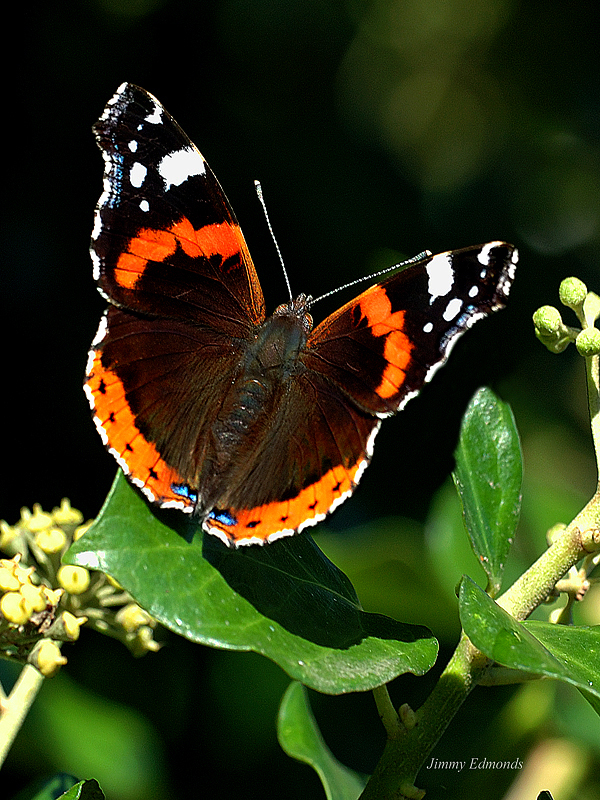

In [21]:
img_path, label = ds_train.dataset.imgs[298]
img = Image.open(img_path)

img

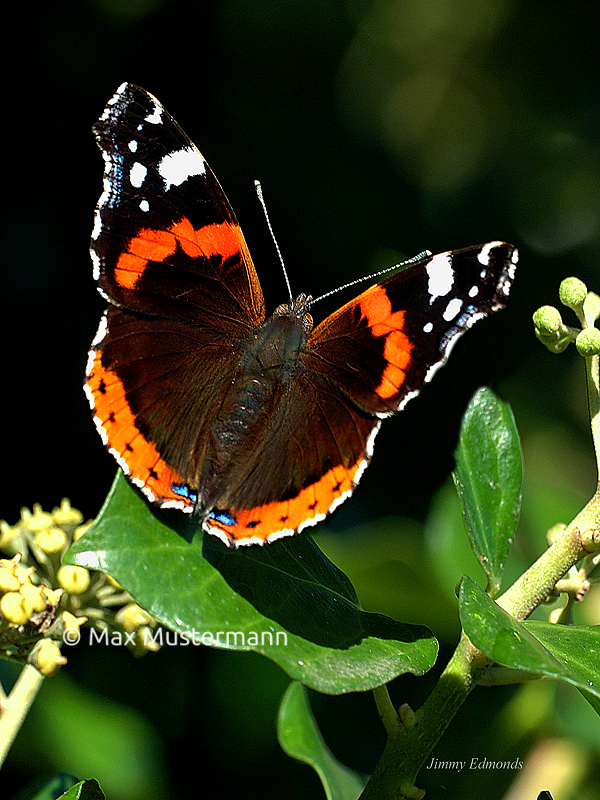

In [40]:
perturbed_img = utils.spurious_feature_generator.imagenet_copyright(img, seed=1)
perturbed_img

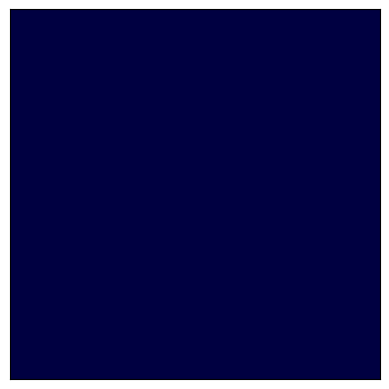

In [41]:
from matplotlib.colors import ListedColormap

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    grid_steps=4,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)

    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

_heatmap(np.zeros((224, 224)))

In [42]:
dataset.input_transformation

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

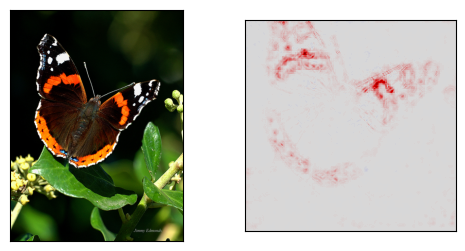

In [43]:
def heatmap(img, label):
    logit_modifier = attributors.WinningClassEvidence(num_classes=len(dataset.selected_classes))

    with Gradient(model=teacher, composite=attributors.get_arch_specific_composite(teacher, lb=low, hb=high)) as attributor:
        x = dataset.input_transformation(img).unsqueeze(0).to(device)
        y = torch.tensor([label]).to(device)
        _, relevance = attributor.forward(x, lambda logits: logit_modifier(logits, y))

        heatmap = relevance.squeeze().sum(axis=0).detach().cpu().numpy()

    plt.figure(figsize=(2*3, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img); plt.xticks([]); plt.yticks([])
    plt.subplot(1, 2, 2)
    _heatmap(heatmap)
    
heatmap(img, label)

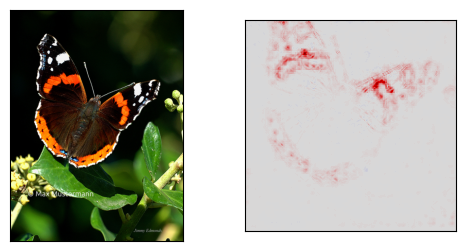

In [44]:
heatmap(perturbed_img, label)

In [45]:
def get_basis(basis_name, k):

    
    arr_act = _arr_act
    arr_ctx = _arr_ctx

    _, d = arr_act.shape

    if basis_name == "pca":
        _, pca_eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
        U = np.flip(pca_eigvecs, axis=1).copy()
        return U[:, :k].copy()

    elif basis_name == "prca-sortabs":
        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-np.abs(eigvals))

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()

    else:
        raise


In [46]:
dimensions = _arr_ctx.shape[1]
dimensions

256

In [47]:
def get_clean_feature_map(x, K=50):
        
    _, arr_outputs = utils.interceptor.forward_and_intercept_intermediate_layers(
        model=teacher, 
        inp=dataset.input_transformation(x).unsqueeze(0).to(device),
        layers=[MAIN_LAYER],
        detach_output=True
    )

    fm = arr_outputs[0].detach().cpu()

    d = arr_outputs[0].shape[1]
    
    original_fm = fm.squeeze()
    arr_fms = [original_fm]
    
    for bix, basis_name in enumerate(["pca", "prca-sortabs"]):
        U = torch.from_numpy(get_basis(basis_name, k=K))
        basis_fm = F.conv2d(
            fm,
            (U@U.T).unsqueeze(2).unsqueeze(3)
        )
        basis_fm = basis_fm.squeeze()
        arr_fms.append(basis_fm)
    return arr_fms

get_clean_feature_map(img)

[tensor([[[0.0225, 0.0000, 0.0000,  ..., 0.2787, 0.1535, 0.3357],
          [0.1991, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.3879, 0.0115, 0.1913,  ..., 0.0000, 0.0703, 0.0000],
          ...,
          [0.0145, 0.0000, 0.3114,  ..., 0.0410, 0.3606, 0.2765],
          [0.0000, 0.0000, 0.0000,  ..., 0.1635, 0.4090, 0.1874],
          [0.3245, 0.0000, 0.0451,  ..., 0.0412, 0.1368, 0.0969]],
 
         [[0.0000, 0.0000, 0.7988,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.2841,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.1378, 0.1619,  ..., 0.1481, 0.0661, 0.0874],
          ...,
          [0.2506, 0.0000, 0.0000,  ..., 0.1377, 0.2005, 0.3915],
          [0.3428, 0.0000, 0.0000,  ..., 0.3425, 0.7343, 0.3749],
          [0.2904, 0.0000, 0.0000,  ..., 0.0599, 0.3258, 0.2999]],
 
         [[0.7269, 0.3356, 0.6848,  ..., 0.5014, 0.9511, 0.5436],
          [0.7113, 0.2268, 0.4093,  ..., 0.1410, 0.5141, 0.3272],
          [0.6311, 0.4858, 0.6226,  ...,

In [74]:
rc_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224)
])

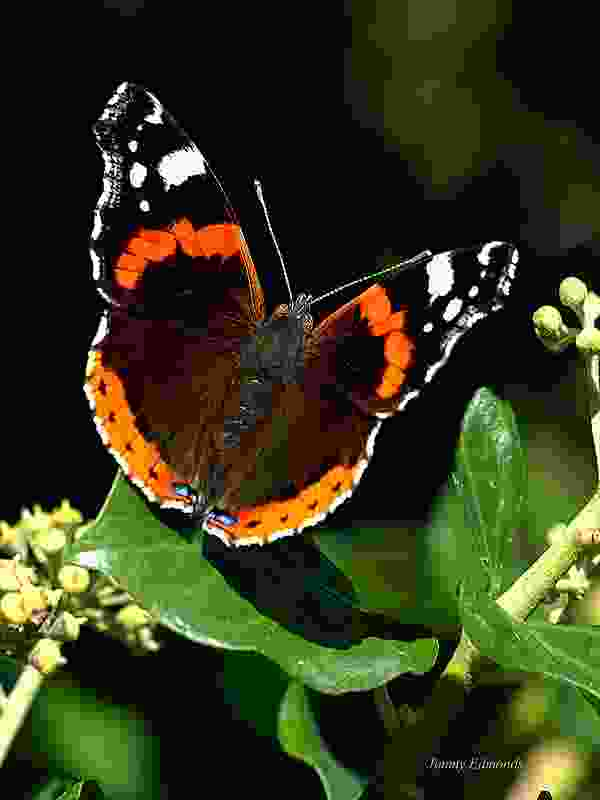

In [85]:
def get_perturb_img(img, spurious_type, seed=1):
    if spurious_type == "watermark":
        return utils.spurious_feature_generator.imagenet_center_watermark(img)
    elif spurious_type == "copyright":
        return utils.spurious_feature_generator.imagenet_copyright(img, seed=seed)
    elif spurious_type == "jpeg":
        return utils.spurious_feature_generator.jpeg_artifact(img)
    else:
        raise

get_perturb_img(img, "jpeg")

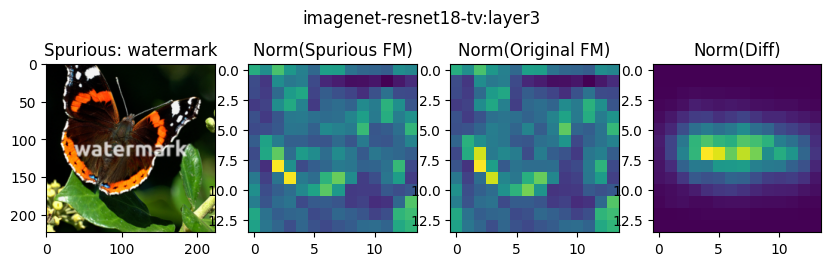

In [132]:
def norm(x):
    assert len(x.shape) == 3
    
    return x.norm(dim=0)

def viz(spurious_type):
    perturbed_img = get_perturb_img(img, spurious_type=spurious_type)

    arr_clean_fms = get_clean_feature_map(img, K=10)
    arr_spurious_fms = get_clean_feature_map(perturbed_img, K=10)
    
    vmax = norm(arr_clean_fms[0]).max()
    vmin = norm(arr_clean_fms[0]).min()
    
    ncols = 4
    nrows = 1

    plt.figure(figsize=(ncols*2.5, 2.5*nrows))
    plt.suptitle(f"{MODEL_NAME}:{MAIN_LAYER}", y=1.05)
    plt.subplot(nrows, ncols, 1)
    plt.title(f"Spurious: {spurious_type}")
    plt.imshow(rc_transform(perturbed_img), vmin=vmin, vmax=vmax)

    plt.subplot(nrows, ncols, 2)
    plt.title("Norm(Spurious FM)")
    plt.imshow(norm(arr_spurious_fms[0]), vmin=vmin, vmax=vmax)

    
    plt.subplot(nrows, ncols, 3)
    plt.title("Norm(Original FM)")
    plt.imshow(norm(arr_clean_fms[0]), vmin=vmin, vmax=vmax)


    plt.subplot(nrows, ncols, 4)
    plt.title("Norm(Diff)")
    ratio = norm(arr_spurious_fms[0] - arr_clean_fms[0])
    plt.imshow(ratio)


viz(spurious_type="watermark")

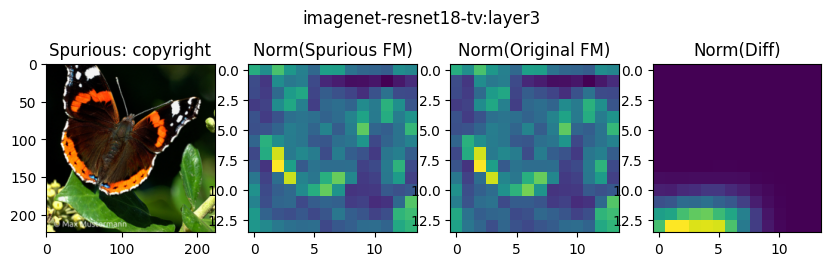

In [133]:
viz(spurious_type="copyright")

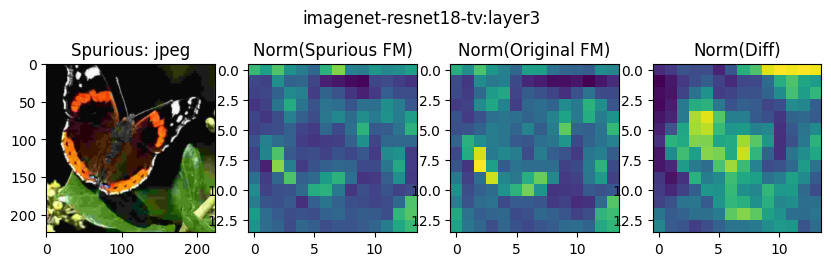

In [134]:
viz(spurious_type="jpeg")

jpeg: 100%|████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.71it/s]


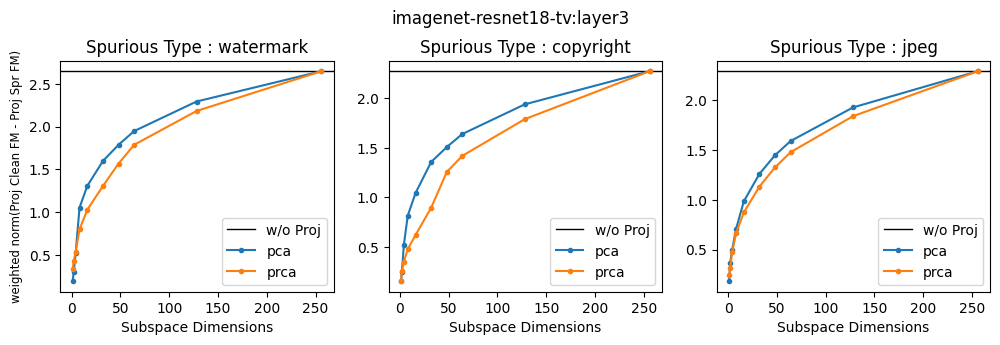

In [136]:
def viz_spurious_filter(arr_spurious_types, arr_ks=[1, 2, 4, 8, 16, 32, 48, 64, 128, 256]):
    ncols = len(arr_spurious_types)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(f"{MODEL_NAME}:{MAIN_LAYER}", y=1.05)
    
    for six, spurious_type in enumerate(arr_spurious_types):
        plt.subplot(1, ncols, six+1)
        plt.title(f'Spurious Type : {spurious_type}')

    
        perturbed_img = get_perturb_img(img, spurious_type=spurious_type)



        fm_ori = get_clean_feature_map(img, K=10)[0]
        fm_spur = get_clean_feature_map(perturbed_img, K=10)[0]

        norm_diff = norm(fm_ori - fm_spur)
        total_error = norm_diff.flatten(start_dim=1).sum()
        beta = norm_diff / total_error

        np.testing.assert_allclose(np.sum(beta.numpy()), 1)
        plt.axhline((norm_diff * beta).sum(), ls="-", lw=1, color="k", label="w/o Proj")
        errors = []

        for k in tqdm(arr_ks, desc=spurious_type):

            _, fm_clean_pca, fm_clean_prca = get_clean_feature_map(img, K=k)

            _, fm_spur_pca, fm_spur_prca = get_clean_feature_map(perturbed_img, K=k)

            errors.append((
                (beta * norm(fm_clean_pca - fm_spur_pca)).sum(),
                (beta * norm(fm_clean_prca - fm_spur_prca)).sum(),
            ))

        errors = np.array(errors)

        for i, label in enumerate(["pca", "prca"]):
            plt.plot(arr_ks, errors[:, i], label=label, marker=".")


        if six == 0:
            plt.ylabel("weighted norm(Proj Clean FM - Proj Spr FM)", fontsize="small")
        plt.xlabel("Subspace Dimensions")
        plt.legend()

viz_spurious_filter(arr_spurious_types=[
    "watermark",
    "copyright",
    "jpeg"
])